In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load and prepare data
df = pd.read_csv('data/final_cleaned.csv')
df = df.dropna()

X = df.drop('ASD_traits', axis=1)
y = df['ASD_traits']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1580, 23)
Testing set size: (396, 23)


Value Counts:
 ASD_traits
1.0    1068
0.0     908
Name: count, dtype: int64

Percentage:
 ASD_traits
1.0    54.048583
0.0    45.951417
Name: proportion, dtype: float64


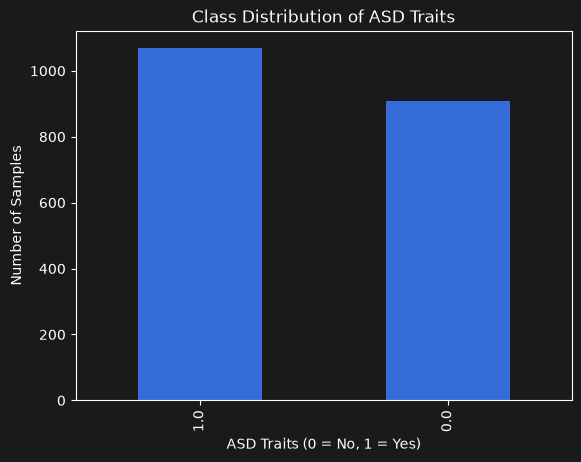

In [2]:
# Check if dataset is balanced or not
print("Value Counts:\n", df['ASD_traits'].value_counts())
print("\nPercentage:\n", df['ASD_traits'].value_counts(normalize=True) * 100)

df['ASD_traits'].value_counts().plot(kind='bar')
plt.title("Class Distribution of ASD Traits")
plt.xlabel("ASD Traits (0 = No, 1 = Yes)")
plt.ylabel("Number of Samples")
plt.show()

In [3]:
# LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 0.8838383838383839

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.88      0.88       185
         1.0       0.89      0.89      0.89       211

    accuracy                           0.88       396
   macro avg       0.88      0.88      0.88       396
weighted avg       0.88      0.88      0.88       396



In [4]:
# L1 Regularization
l1_model = LogisticRegression(
    l1_ratio=1.0, solver='liblinear', max_iter=1000, random_state=42
)

# L2 Regularization
l2_model = LogisticRegression(
    l1_ratio=0.0, solver='lbfgs', max_iter=1000, random_state=42
)

# Fit the models
l1_model.fit(X_train, y_train)
l2_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [5]:
# Test accuracies
l1_test_acc = accuracy_score(y_test, l1_model.predict(X_test))
l2_test_acc = accuracy_score(y_test, l2_model.predict(X_test))

print("Logistic Regression Test Accuracies:")
print(f"L1 Regularization Accuracy: {l1_test_acc:.4f}")
print(f"L2 Regularization Accuracy: {l2_test_acc:.4f}")

# Select best model
if l1_test_acc > l2_test_acc:
    best_model = l1_model
    print("\nSelected Model: L1 Logistic Regression")
else:
    best_model = l2_model
    print("\nSelected Model: L2 Logistic Regression")

Logistic Regression Test Accuracies:
L1 Regularization Accuracy: 0.9116
L2 Regularization Accuracy: 0.8838

Selected Model: L1 Logistic Regression


=== Logistic Regression: Original Test Set ===
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.90       185
         1.0       0.91      0.92      0.92       211

    accuracy                           0.91       396
   macro avg       0.91      0.91      0.91       396
weighted avg       0.91      0.91      0.91       396



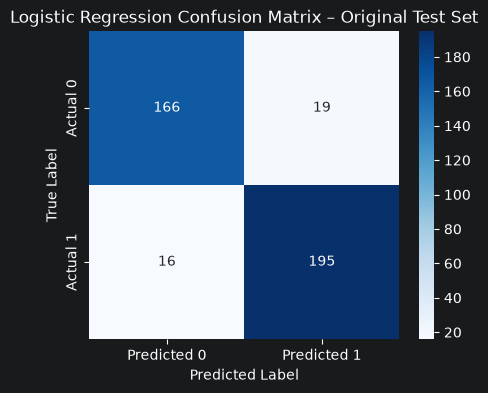

In [6]:
y_test_pred = best_model.predict(X_test)

print("=== Logistic Regression: Original Test Set ===")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Logistic Regression Confusion Matrix – Original Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


=== Logistic Regression: Test Dataset 1 ===
Accuracy: 0.9091
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90        95
         1.0       0.90      0.92      0.91       103

    accuracy                           0.91       198
   macro avg       0.91      0.91      0.91       198
weighted avg       0.91      0.91      0.91       198



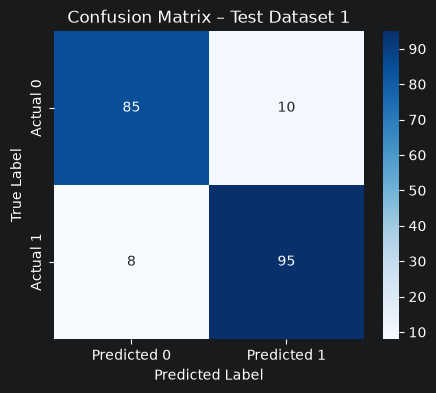


=== Logistic Regression: Test Dataset 2 ===
Accuracy: 0.9141
              precision    recall  f1-score   support

         0.0       0.91      0.90      0.91        90
         1.0       0.92      0.93      0.92       108

    accuracy                           0.91       198
   macro avg       0.91      0.91      0.91       198
weighted avg       0.91      0.91      0.91       198



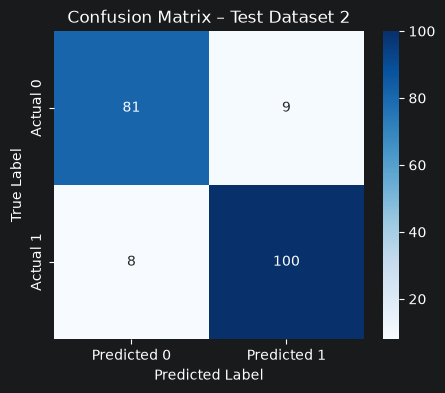

In [7]:
# Create the subsets
X_test1, X_test2, y_test1, y_test2 = train_test_split(
    X_test, y_test, test_size=0.5, random_state=42
)

for Xt, yt, name in [
    (X_test1, y_test1, "Test Dataset 1"),
    (X_test2, y_test2, "Test Dataset 2")
]:
    y_pred = best_model.predict(Xt)

    print(f"\n=== Logistic Regression: {name} ===")
    print(f"Accuracy: {accuracy_score(yt, y_pred):.4f}")
    print(classification_report(yt, y_pred))

    # Confusion matrix
    cm = confusion_matrix(yt, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f"Confusion Matrix – {name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

Best K: 11
Best Accuracy: 0.9373


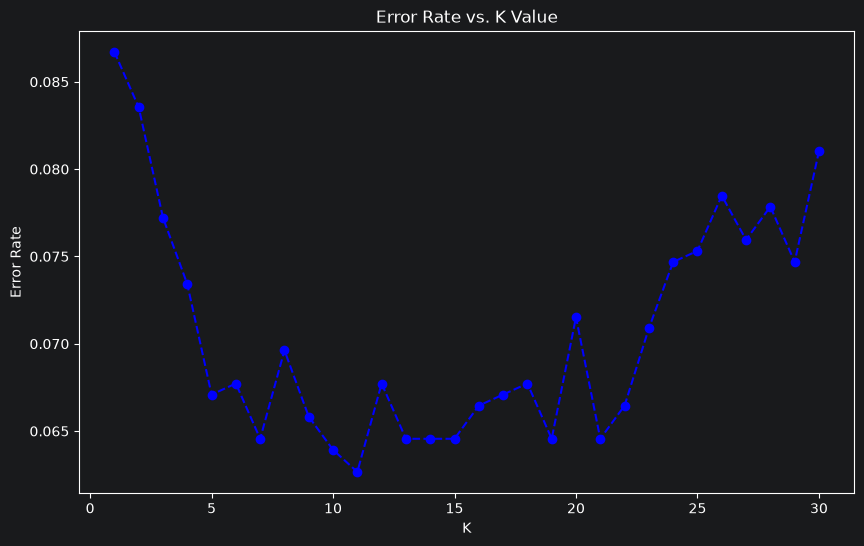

In [8]:
# K NEAREST NEIGHBOR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
k_range = list(range(1, 31))

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': k_range},
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train_scaled, y_train)

best_k = grid.best_params_['n_neighbors']
print("Best K:", best_k)
print(f"Best Accuracy: {grid.best_score_:.4f}")

# Calculate error rates for each K manually for the plot
error_rate = []
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    # Using cross_val_score for a stable mean error
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5)
    error_rate.append(1 - scores.mean())

# Plotting
plt.figure(figsize=(10,6))
plt.plot(k_range, error_rate, color='blue', linestyle='dashed', marker='o')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

=== KNN: Original Test Set ===
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93       185
         1.0       0.94      0.94      0.94       211

    accuracy                           0.94       396
   macro avg       0.94      0.94      0.94       396
weighted avg       0.94      0.94      0.94       396



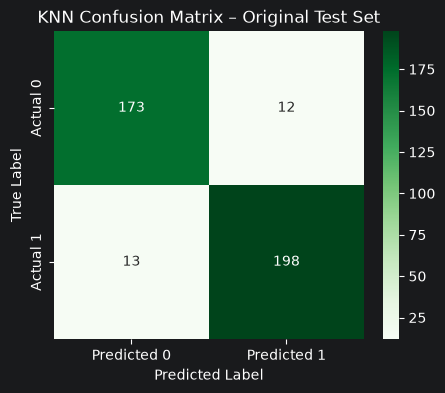

In [9]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

X_test_scaled = scaler.transform(X_test)
y_pred_test = knn_final.predict(X_test_scaled)

print("=== KNN: Original Test Set ===")
print(classification_report(y_test, y_pred_test))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("KNN Confusion Matrix – Original Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


=== KNN: Test Dataset 1 ===
Accuracy: 0.9343
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93        95
         1.0       0.94      0.93      0.94       103

    accuracy                           0.93       198
   macro avg       0.93      0.93      0.93       198
weighted avg       0.93      0.93      0.93       198



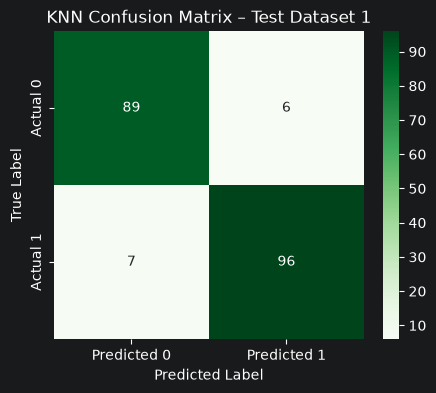


=== KNN: Test Dataset 2 ===
Accuracy: 0.9394
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93        90
         1.0       0.94      0.94      0.94       108

    accuracy                           0.94       198
   macro avg       0.94      0.94      0.94       198
weighted avg       0.94      0.94      0.94       198



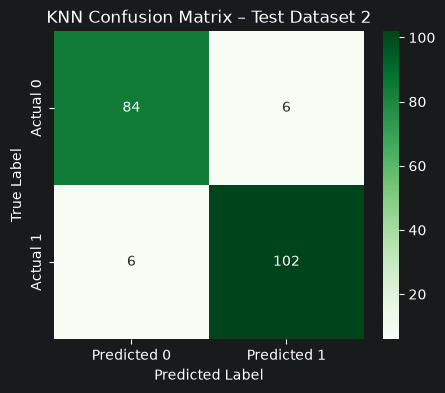

In [10]:
# Already scaled using the training scaler
X_test1_scaled = scaler.transform(X_test1)
X_test2_scaled = scaler.transform(X_test2)

for Xt, yt, name in [
    (X_test1_scaled, y_test1, "Test Dataset 1"),
    (X_test2_scaled, y_test2, "Test Dataset 2")
]:
    y_pred = knn_final.predict(Xt)

    print(f"\n=== KNN: {name} ===")
    print(f"Accuracy: {accuracy_score(yt, y_pred):.4f}")
    print(classification_report(yt, y_pred))

    # Confusion matrix
    cm = confusion_matrix(yt, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f"KNN Confusion Matrix – {name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

=== Naive Bayes – Original Test Set ===
Accuracy: 0.7146
              precision    recall  f1-score   support

         0.0       0.67      0.77      0.72       185
         1.0       0.77      0.67      0.71       211

    accuracy                           0.71       396
   macro avg       0.72      0.72      0.71       396
weighted avg       0.72      0.71      0.71       396

Confusion Matrix (text):


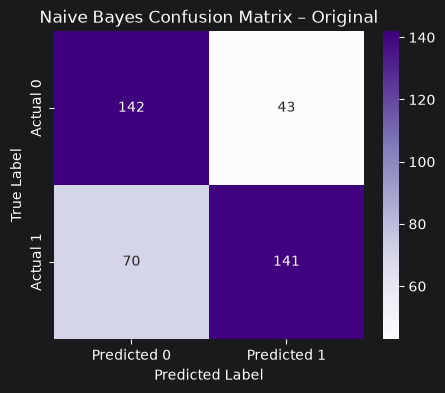

In [11]:
# NAIVE BAYES - Gaussian
from sklearn.naive_bayes import GaussianNB

# Train once
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Predictions on original test set
y_pred = nb_model.predict(X_test)

print("=== Naive Bayes – Original Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (text):")
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("Naive Bayes Confusion Matrix – Original")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [12]:
# Check for overfitting / underfitting
# Training accuracy
train_acc = nb_model.score(X_train, y_train)
# Testing accuracy
test_acc = nb_model.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Difference:        {train_acc - test_acc:.4f}")

# Interpretation
if train_acc - test_acc > 0.1:
    print("Model is likely OVERFITTING")
elif train_acc < 0.7 and test_acc < 0.7:
    print("Model is likely UNDERFITTING")
else:
    print("Model is well-fitted")

Training Accuracy: 0.7203
Testing Accuracy:  0.7146
Difference:        0.0056
Model is well-fitted



=== Naive Bayes: Test Dataset 1 ===
Accuracy: 0.7121
              precision    recall  f1-score   support

         0.0       0.68      0.77      0.72        95
         1.0       0.76      0.66      0.70       103

    accuracy                           0.71       198
   macro avg       0.72      0.71      0.71       198
weighted avg       0.72      0.71      0.71       198



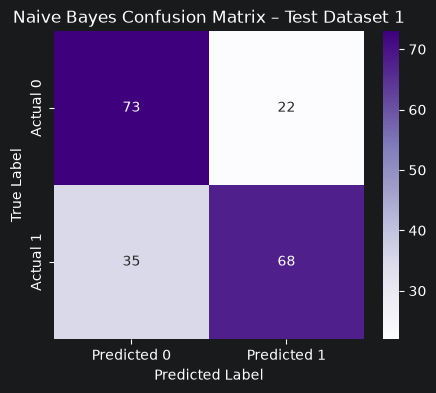


=== Naive Bayes: Test Dataset 2 ===
Accuracy: 0.7172
              precision    recall  f1-score   support

         0.0       0.66      0.77      0.71        90
         1.0       0.78      0.68      0.72       108

    accuracy                           0.72       198
   macro avg       0.72      0.72      0.72       198
weighted avg       0.73      0.72      0.72       198



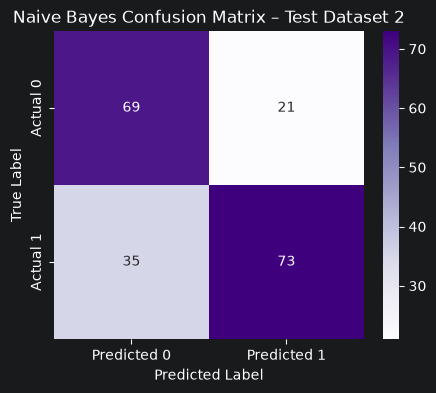

In [13]:
# TESTING ON 2 NEW DATASETS FOR NAIVE BAYES
for Xt, yt, name in [
    (X_test1, y_test1, "Test Dataset 1"),
    (X_test2, y_test2, "Test Dataset 2")
]:
    y_pred = nb_model.predict(Xt)
    print(f"\n=== Naive Bayes: {name} ===")
    print(f"Accuracy: {accuracy_score(yt, y_pred):.4f}")
    print(classification_report(yt, y_pred))

    cm = confusion_matrix(yt, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f"Naive Bayes Confusion Matrix – {name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

Training Accuracy: 0.9538
Original Test Accuracy: 0.9596

=== Decision Tree – Original Test Set ===
Accuracy: 0.9596
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96       185
         1.0       0.96      0.97      0.96       211

    accuracy                           0.96       396
   macro avg       0.96      0.96      0.96       396
weighted avg       0.96      0.96      0.96       396



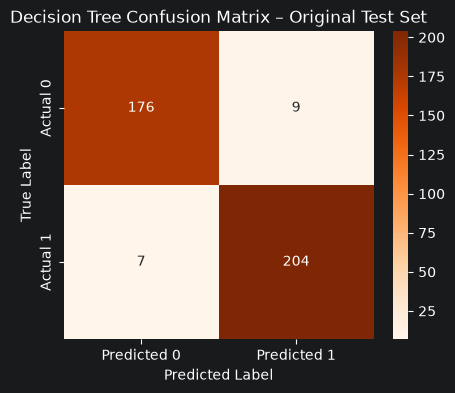

In [14]:
# DECISION TREE
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Training and original test accuracy
train_acc = clf.score(X_train, y_train)
test_acc  = clf.score(X_test, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Original Test Accuracy: {test_acc:.4f}")

y_pred = clf.predict(X_test)

print("\n=== Decision Tree – Original Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

# Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree Confusion Matrix – Original Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


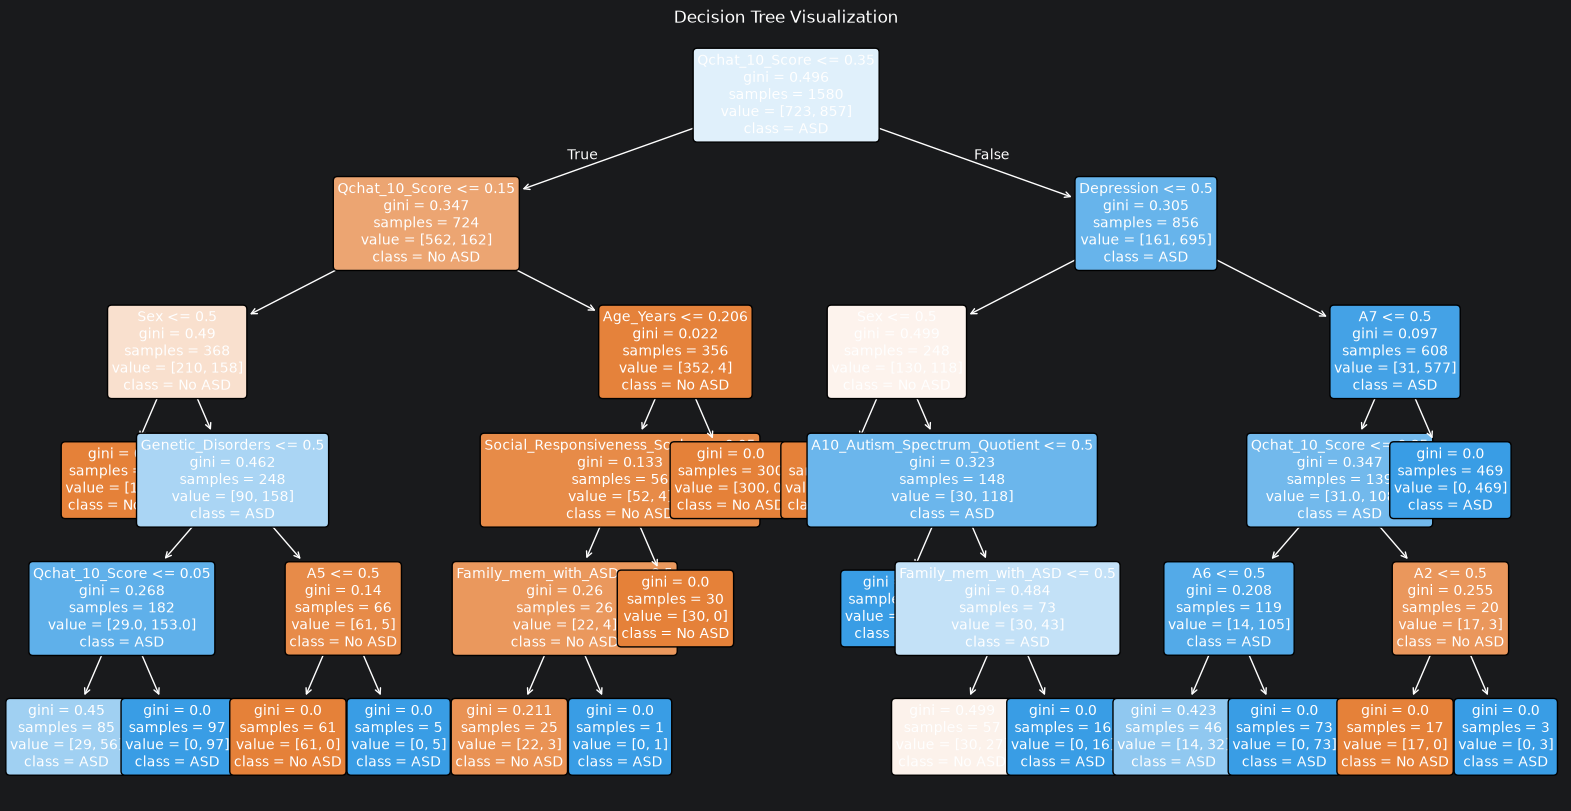

In [15]:
# Decision Tree visualization
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['No ASD', 'ASD'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization")
plt.show()


=== Decision Tree – Test Dataset 1 ===
Accuracy: 0.9545
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95        95
         1.0       0.95      0.96      0.96       103

    accuracy                           0.95       198
   macro avg       0.95      0.95      0.95       198
weighted avg       0.95      0.95      0.95       198



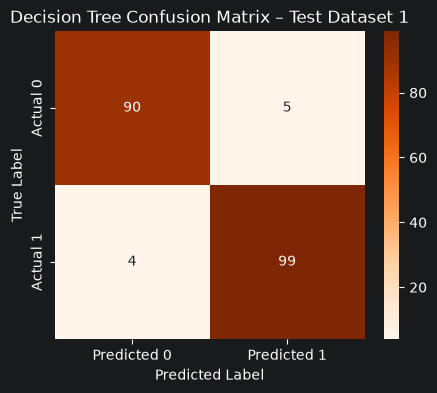


=== Decision Tree – Test Dataset 2 ===
Accuracy: 0.9646
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96        90
         1.0       0.96      0.97      0.97       108

    accuracy                           0.96       198
   macro avg       0.96      0.96      0.96       198
weighted avg       0.96      0.96      0.96       198



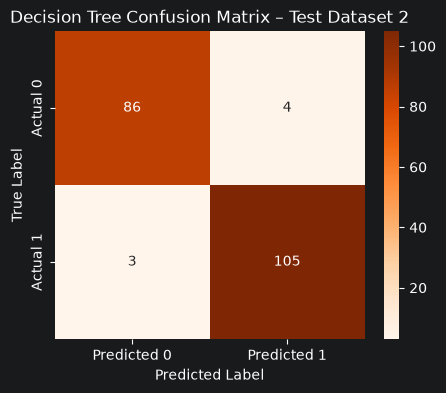

In [16]:
# TESTING ON 2 NEW DATASETS FOR DECISION TREE
for Xt, yt, name in [
    (X_test1, y_test1, "Test Dataset 1"),
    (X_test2, y_test2, "Test Dataset 2")
]:
    y_pred = clf.predict(Xt)
    print(f"\n=== Decision Tree – {name} ===")
    print(f"Accuracy: {accuracy_score(yt, y_pred):.4f}")
    print(classification_report(yt, y_pred))

    # Confusion matrix
    cm = confusion_matrix(yt, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )

    # Heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Oranges')
    plt.title(f"Decision Tree Confusion Matrix – {name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

=== SVM RBF – Original Test Set ===
Accuracy: 0.9318
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93       185
         1.0       0.96      0.91      0.93       211

    accuracy                           0.93       396
   macro avg       0.93      0.93      0.93       396
weighted avg       0.93      0.93      0.93       396



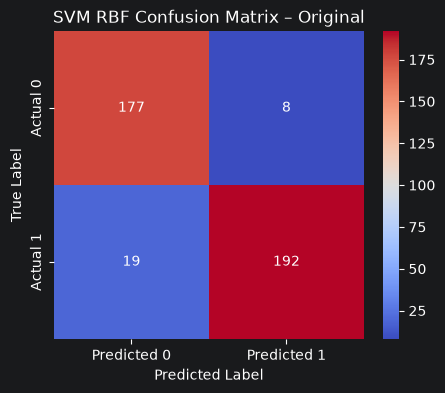

In [17]:
# SVM - RBF
from sklearn.svm import SVC

# Scale features (if not already scaled in KNN block, else redefine)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with RBF kernel
svm_model = SVC(kernel='rbf', C=3.0, gamma='scale', class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions on original test set
y_pred = svm_model.predict(X_test_scaled)

print("=== SVM RBF – Original Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred) # Fixed: Calculate CM before plotting
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title("SVM RBF Confusion Matrix – Original")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

In [18]:
# Check for overfitting / underfitting (SVM)
# Training accuracy
train_acc = svm_model.score(X_train_scaled, y_train)
# Testing accuracy
test_acc = svm_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Difference:        {train_acc - test_acc:.4f}")

# Interpretation
if train_acc - test_acc > 0.1:
    print("Model is likely OVERFITTING")
elif train_acc < 0.7 and test_acc < 0.7:
    print("Model is likely UNDERFITTING")
else:
    print("Model is well-fitted")

Training Accuracy: 0.9367
Testing Accuracy:  0.9318
Difference:        0.0049
Model is well-fitted



=== SVM RBF: Test Dataset 1 ===
Accuracy: 0.9293
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93        95
         1.0       0.96      0.90      0.93       103

    accuracy                           0.93       198
   macro avg       0.93      0.93      0.93       198
weighted avg       0.93      0.93      0.93       198



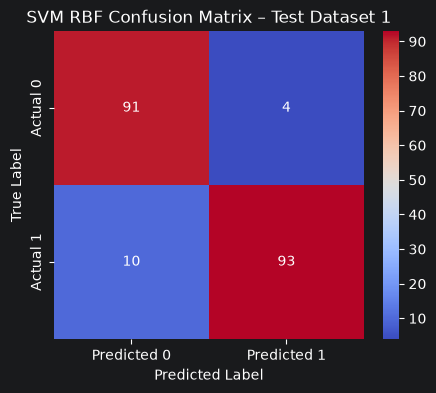


=== SVM RBF: Test Dataset 2 ===
Accuracy: 0.9343
              precision    recall  f1-score   support

         0.0       0.91      0.96      0.93        90
         1.0       0.96      0.92      0.94       108

    accuracy                           0.93       198
   macro avg       0.93      0.94      0.93       198
weighted avg       0.94      0.93      0.93       198



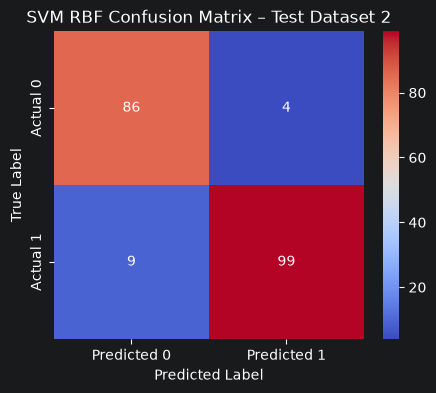

In [19]:
# TESTING ON 2 NEW DATASETS FOR SVM
# Scale the new test datasets using SAME scaler
X_test1_scaled = scaler.transform(X_test1)
X_test2_scaled = scaler.transform(X_test2)

# Predictions on the two splits
for Xt, yt, name in [
    (X_test1_scaled, y_test1, "Test Dataset 1"),
    (X_test2_scaled, y_test2, "Test Dataset 2")
]:
    y_pred = svm_model.predict(Xt)
    print(f"\n=== SVM RBF: {name} ===")
    print(f"Accuracy: {accuracy_score(yt, y_pred):.4f}")
    print(classification_report(yt, y_pred))

    cm = confusion_matrix(yt, y_pred) # Fixed: recalculate CM for subset
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f"SVM RBF Confusion Matrix – {name}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

In [20]:
# Finding the best performing supervised model
# Collect predictions from all your trained supervised models
from sklearn.metrics import f1_score

supervised_candidates = {}

# Base Logistic Regression
try:
    supervised_candidates["Logistic Regression"] = model.predict(X_test)
except NameError:
    pass

# L1 Logistic Regression
try:
    supervised_candidates["L1 Logistic Regression"] = l1_model.predict(X_test)
except NameError:
    pass

# L2 Logistic Regression
try:
    supervised_candidates["L2 Logistic Regression"] = l2_model.predict(X_test)
except NameError:
    pass

# KNN (requires scaled test data)
try:
    supervised_candidates["K-Nearest Neighbors (KNN)"] = knn_final.predict(X_test_scaled)
except NameError:
    pass

# Gaussian Naive Bayes
try:
    supervised_candidates["Gaussian Naive Bayes"] = nb_model.predict(X_test)
except NameError:
    pass

# Decision Tree
try:
    supervised_candidates["Decision Tree"] = clf.predict(X_test)
except NameError:
    pass

# SVM RBF (requires scaled test data)
try:
    supervised_candidates["Support Vector Machine (SVM)"] = svm_model.predict(X_test_scaled)
except NameError:
    pass

# Evaluate and find the best supervised model
sup_results_summary = []

print(f"{'Model Name':<32} | {'Accuracy':<10} | {'F1-Score':<10}")
print("-" * 55)

for name, preds in supervised_candidates.items():
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, zero_division=0)

    sup_results_summary.append({"name": name, "accuracy": acc, "f1": f1})
    print(f"{name:<32} | {acc*100:6.2f}%    | {f1:6.4f}")


# Determine the absolute winner based on Accuracy (and fallback to F1)
best_sup_model = max(sup_results_summary, key=lambda x: (x["accuracy"], x["f1"]))

print(f"\nBEST PERFORMING SUPERVISED MODEL:")
print(f"-> {best_sup_model['name']} predicted the most correctly with an Accuracy of {best_sup_model['accuracy']*100:.2f}% and an F1-Score of {best_sup_model['f1']:.4f}.\n")

Model Name                       | Accuracy   | F1-Score  
-------------------------------------------------------
Logistic Regression              |  88.38%    | 0.8905
L1 Logistic Regression           |  91.16%    | 0.9176
L2 Logistic Regression           |  88.38%    | 0.8905
K-Nearest Neighbors (KNN)        |  93.69%    | 0.9406
Gaussian Naive Bayes             |  71.46%    | 0.7139
Decision Tree                    |  95.96%    | 0.9623
Support Vector Machine (SVM)     |  93.18%    | 0.9343

BEST PERFORMING SUPERVISED MODEL:
-> Decision Tree predicted the most correctly with an Accuracy of 95.96% and an F1-Score of 0.9623.



In [28]:
import joblib

# Save Decision Tree
joblib.dump(clf, "supervised_models/decision_tree.pkl")

# Save KNN (extract the best model from GridSearchCV)
joblib.dump(grid.best_estimator_, "supervised_models/knn.pkl")

# Save SVM
joblib.dump(svm_model, "supervised_models/svm.pkl")

# Save Naive Bayes
joblib.dump(nb_model, "supervised_models/naive_bayes.pkl")

# Save L1 Logistic Regression
joblib.dump(l1_model, "supervised_models/l1_logistic.pkl")
joblib.dump(l2_model, "supervised_models/l2_logistic.pkl")
joblib.dump(model, "supervised_models/logistic.pkl")

joblib.dump(scaler, "supervised_models/scaler.pkl")

['supervised_models/scaler.pkl']